In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import Timestamp

In [3]:
df = pd.read_csv('/content/online_retail.csv')
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58300 entries, 0 to 58299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        58300 non-null  int64  
 1   InvoiceNo    58300 non-null  object 
 2   StockCode    58300 non-null  object 
 3   Description  58139 non-null  object 
 4   Quantity     58300 non-null  int64  
 5   InvoiceDate  58300 non-null  object 
 6   UnitPrice    58300 non-null  float64
 7   CustomerID   36392 non-null  float64
 8   Country      58300 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 4.0+ MB


In [5]:
df.shape

(58300, 9)

Removes the redundant 'index' column.

In [6]:
df = df.drop(columns=['index'])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Converts 'InvoiceDate' to datetime objects and shows descriptive statistics.

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed', errors='coerce')

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,58300.000000,58300,58300.000000,36392.000000
mean,8.523087,2010-12-18 20:14:22.307032576,6.074295,15390.736068
min,-9360.000000,2010-12-01 08:26:00,0.000000,12347.000000
25%,1.000000,2010-12-07 13:01:00,1.250000,14031.000000
50%,2.000000,2010-12-14 10:46:00,2.510000,15379.000000
75%,8.000000,2011-01-05 10:08:00,4.250000,17017.000000
max,3114.000000,2011-01-14 14:47:00,16888.020000,18283.000000
std,57.440390,NaN,154.306236,1757.284043


Checks for missing values and their percentages.

In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,161
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,21908
Country,0


In [9]:
df.isnull().sum()/len(df)

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.002762
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,0.375780
Country,0.000000


Filters and displays rows with missing 'CustomerID' or 'Description'.

In [10]:
df[df['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
58213,541221,22111,SCOTTIE DOG HOT WATER BOTTLE,8,2011-01-14 14:28:00,5.79,NaN,United Kingdom
58214,541221,22112,CHOCOLATE HOT WATER BOTTLE,8,2011-01-14 14:28:00,5.79,NaN,United Kingdom
58215,541221,22326,ROUND SNACK BOXES SET OF4 WOODLAND,4,2011-01-14 14:28:00,6.63,NaN,United Kingdom
58216,541221,22327,ROUND SNACK BOXES SET OF 4 SKULLS,3,2011-01-14 14:28:00,6.63,NaN,United Kingdom


Filters and displays rows with missing 'Description'.

In [11]:
df[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
52262,540699,POST,NaN,1000,2011-01-11 09:32:00,0.0,NaN,United Kingdom
52379,540778,84029E,NaN,-50,2011-01-11 11:15:00,0.0,NaN,United Kingdom
55270,540982,22323,NaN,1,2011-01-12 15:35:00,0.0,NaN,United Kingdom
55319,540987,17011A,NaN,-61,2011-01-12 16:15:00,0.0,NaN,United Kingdom


Drops rows with null 'CustomerID' and checks remaining nulls. This implicitly handles description nulls in these rows.

In [12]:
df = df.dropna(subset=['CustomerID'], axis=0)

df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


Checks for and removes duplicate rows, then displays the new shape.

In [13]:
df.duplicated().sum()

np.int64(560)

Confirms no more duplicates.

In [14]:
df = df.drop_duplicates()

df.shape

(35832, 8)

Confirms the data types and non-null counts after cleaning.

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35832 entries, 0 to 58299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    35832 non-null  object        
 1   StockCode    35832 non-null  object        
 2   Description  35832 non-null  object        
 3   Quantity     35832 non-null  int64         
 4   InvoiceDate  35832 non-null  datetime64[ns]
 5   UnitPrice    35832 non-null  float64       
 6   CustomerID   35832 non-null  float64       
 7   Country      35832 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 2.5+ MB


This section handles anomalies like cancelled orders and zero unit prices.

## Handling Anomalies or Irrevalent Data

In [17]:
df['InvoiceNo'].value_counts()

,count
InvoiceNo,
540372,171
540247,155
537224,152
540458,149
537781,136
...,...
540262,1
C537143,1
537194,1


Identifies and counts `InvoiceNo` starting with 'C', indicating cancellations.

In [18]:
df['InvoiceNo'].str.startswith('C').sum()

np.int64(959)

Removes cancelled orders and updates descriptive statistics.

In [19]:
df = df[~df['InvoiceNo'].str.startswith('C')]

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,34873.000000,34873,34873.000000,34873.000000
mean,13.008947,2010-12-18 01:52:39.195366144,3.153034,15390.880050
min,1.000000,2010-12-01 08:26:00,0.000000,12347.000000
25%,2.000000,2010-12-06 13:34:00,1.250000,14031.000000
50%,5.000000,2010-12-13 13:25:00,2.100000,15379.000000
75%,12.000000,2011-01-04 14:12:00,3.750000,17019.000000
max,3114.000000,2011-01-14 14:47:00,295.000000,18283.000000
std,50.566252,NaN,5.397366,1761.580685


Confirms all cancelled orders are removed.

In [20]:
df['InvoiceNo'].str.startswith('C').sum()

np.int64(0)

Identifies and displays records with `UnitPrice` <= 0.

In [21]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom


Removes records where `UnitPrice` is not positive.

In [22]:
# keeping price greater than 0
df = df[df['UnitPrice'] > 0]

Calculates 'Revenue' as `Quantity` * `UnitPrice`.

In [23]:
# Calculate TotalPrice or Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

Displays the first few rows with the new 'Revenue' column.

In [24]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Shows updated DataFrame information.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34867 entries, 0 to 58299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    34867 non-null  object        
 1   StockCode    34867 non-null  object        
 2   Description  34867 non-null  object        
 3   Quantity     34867 non-null  int64         
 4   InvoiceDate  34867 non-null  datetime64[ns]
 5   UnitPrice    34867 non-null  float64       
 6   CustomerID   34867 non-null  float64       
 7   Country      34867 non-null  object        
 8   Revenue      34867 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 2.7+ MB


Explores specific `UnitPrice` values.

In [26]:
df[df['UnitPrice'] == 3.39000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
50,536373,71053,WHITE METAL LANTERN,6,2010-12-01 09:02:00,3.39,17850.0,United Kingdom,20.34
61,536373,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 09:02:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
52419,540785,84997A,GREEN 3 PIECE POLKADOT CUTLERY SET,144,2011-01-11 11:39:00,3.39,12557.0,Spain,488.16
54304,540908,82001S,VINYL RECORD FRAME SILVER,48,2011-01-12 11:53:00,3.39,12980.0,United Kingdom,162.72
54587,540957,82001S,VINYL RECORD FRAME SILVER,24,2011-01-12 13:30:00,3.39,15311.0,United Kingdom,81.36
57400,541206,21430,SET/3 RED GINGHAM ROSE STORAGE BOX,72,2011-01-14 12:24:00,3.39,14646.0,Netherlands,244.08


Explores records with specific 'Quantity' and 'Description'.

In [27]:
# analyzing quantity feature
df[df['Quantity'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


Explores records with specific 'Quantity' and 'Description'.

In [28]:
df[df['Quantity'] == 80.000000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom,204.0
1228,536531,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 13:23:00,2.55,15485.0,United Kingdom,204.0
1333,536536,84879,ASSORTED COLOUR BIRD ORNAMENT,80,2010-12-01 13:45:00,1.69,18144.0,United Kingdom,135.2
5226,536848,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,80,2010-12-03 09:39:00,2.55,13408.0,United Kingdom,204.0
7432,537038,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-05 10:12:00,2.55,15465.0,United Kingdom,204.0
9167,537194,22619,SET OF 6 SOLDIER SKITTLES,80,2010-12-05 13:53:00,3.39,17402.0,United Kingdom,271.2
13266,537433,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-06 16:36:00,2.55,12913.0,United Kingdom,204.0
14293,537484,22469,HEART OF WICKER SMALL,80,2010-12-07 11:30:00,1.45,14733.0,United Kingdom,116.0
14298,537484,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-07 11:30:00,2.55,14733.0,United Kingdom,204.0
14784,537618,22423,REGENCY CAKESTAND 3 TIER,80,2010-12-07 13:50:00,10.95,15061.0,United Kingdom,876.0


Explores records with specific 'Description'.

In [29]:
df[df['Description'] == 'CHRISTMAS CRAFT TREE TOP ANGEL']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
574,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom,2.1
4972,536833,22141,CHRISTMAS CRAFT TREE TOP ANGEL,6,2010-12-02 17:48:00,2.10,18239.0,United Kingdom,12.6
5208,536846,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-02 19:59:00,2.10,14573.0,United Kingdom,2.1
6590,536960,22141,CHRISTMAS CRAFT TREE TOP ANGEL,6,2010-12-03 12:48:00,2.10,16477.0,United Kingdom,12.6
7129,536989,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-03 15:10:00,2.10,17238.0,United Kingdom,2.1
7762,537054,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-05 11:40:00,2.10,16931.0,United Kingdom,2.1
8085,537126,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-05 12:13:00,2.10,18118.0,United Kingdom,2.1
8445,537135,22141,CHRISTMAS CRAFT TREE TOP ANGEL,3,2010-12-05 12:35:00,2.10,17059.0,United Kingdom,6.3
8814,537153,22141,CHRISTMAS CRAFT TREE TOP ANGEL,6,2010-12-05 13:03:00,2.10,16718.0,United Kingdom,12.6
8887,537154,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-05 13:05:00,2.10,15808.0,United Kingdom,2.1


Explores records with specific 'CustomerID'.

In [30]:
df[df['CustomerID'] == 17238.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
7074,536988,22086,PAPER CHAIN KIT 50'S CHRISTMAS,2,2010-12-03 15:05:00,2.95,17238.0,United Kingdom,5.90
7075,536988,21918,SET 12 KIDS COLOUR CHALK STICKS,1,2010-12-03 15:05:00,0.42,17238.0,United Kingdom,0.42
7076,536988,47343A,FUSCHIA FLOWER PURSE WITH BEADS,3,2010-12-03 15:05:00,1.49,17238.0,United Kingdom,4.47
7077,536988,22142,CHRISTMAS CRAFT WHITE FAIRY,2,2010-12-03 15:05:00,1.45,17238.0,United Kingdom,2.90
7078,536988,21098,CHRISTMAS TOILET ROLL,1,2010-12-03 15:05:00,1.25,17238.0,United Kingdom,1.25
7079,536988,22352,LUNCH BOX WITH CUTLERY RETROSPOT,2,2010-12-03 15:05:00,2.55,17238.0,United Kingdom,5.10
7080,536988,22865,HAND WARMER OWL DESIGN,2,2010-12-03 15:05:00,2.10,17238.0,United Kingdom,4.20
7081,536988,22632,HAND WARMER RED RETROSPOT,3,2010-12-03 15:05:00,2.10,17238.0,United Kingdom,6.30
7082,536988,22144,CHRISTMAS CRAFT LITTLE FRIENDS,2,2010-12-03 15:05:00,2.10,17238.0,United Kingdom,4.20
7083,536988,22964,3 PIECE SPACEBOY COOKIE CUTTER SET,3,2010-12-03 15:05:00,2.10,17238.0,United Kingdom,6.30


Explores records with specific 'CustomerID'.

In [31]:
df[df['CustomerID'] == 13319.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
19754,537889,21671,RED SPOT CERAMIC DRAWER KNOB,12,2010-12-09 10:04:00,1.25,13319.0,United Kingdom,15.00
19755,537889,21485,RETROSPOT HEART HOT WATER BOTTLE,9,2010-12-09 10:04:00,4.95,13319.0,United Kingdom,44.55
19756,537889,21673,WHITE SPOT BLUE CERAMIC DRAWER KNOB,12,2010-12-09 10:04:00,1.25,13319.0,United Kingdom,15.00
19757,537889,22180,RETROSPOT LAMP,1,2010-12-09 10:04:00,9.95,13319.0,United Kingdom,9.95
19758,537889,21527,RED RETROSPOT TRADITIONAL TEAPOT,4,2010-12-09 10:04:00,7.95,13319.0,United Kingdom,31.80
...,...,...,...,...,...,...,...,...,...
42682,540015,22072,RED RETROSPOT TEA CUP AND SAUCER,4,2011-01-04 11:40:00,3.75,13319.0,United Kingdom,15.00
42683,540015,84879,ASSORTED COLOUR BIRD ORNAMENT,16,2011-01-04 11:40:00,1.69,13319.0,United Kingdom,27.04
42684,540015,22914,BLUE COAT RACK PARIS FASHION,3,2011-01-04 11:40:00,4.95,13319.0,United Kingdom,14.85
42685,540015,22913,RED COAT RACK PARIS FASHION,3,2011-01-04 11:40:00,4.95,13319.0,United Kingdom,14.85


Explores records with 'Quantity' >= 10000.

In [32]:
df[df['Quantity'] >= 10000.000000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


In [33]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Displays the shape of the cleaned DataFrame.

In [34]:
df.shape

(34867, 9)

##Visualizations

In [35]:
country_count = df.groupby('Country')['CustomerID'].count().sort_values(ascending=False).head()

Calculates and stores the top 5 countries by customer count.

In [36]:
country_count

,CustomerID
Country,
United Kingdom,31335
France,833
Germany,819
EIRE,387
Spain,301


Displays the top 5 countries by customer count, then visualizes them with a bar chart.

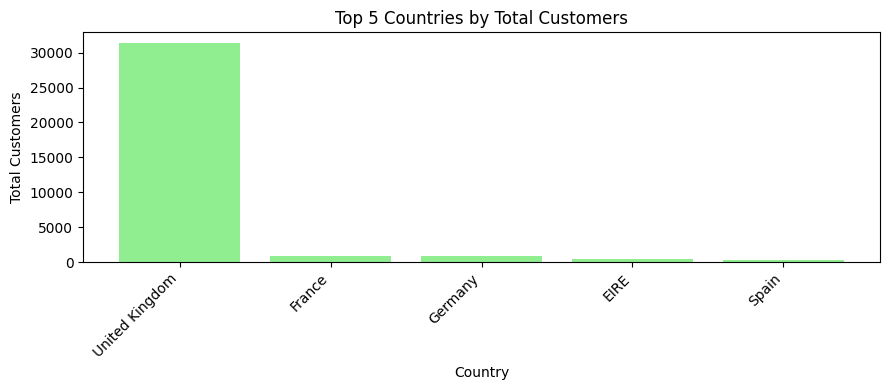

In [37]:
plt.figure(figsize=(9,4))

plt.bar(country_count.index, country_count.values, color='lightgreen')
plt.title('Top 5 Countries by Total Customers')
plt.xlabel('Country')
plt.ylabel('Total Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Calculates and stores the top 10 countries by total revenue.

In [38]:
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

Displays the top 10 countries by total revenue, then visualizes them with a bar chart.

In [39]:
country_rev

,Revenue
Country,
United Kingdom,694822.02
EIRE,25846.60
Germany,21546.58
Netherlands,19173.54
France,18942.36
Spain,9262.55
Australia,8840.83
Japan,7705.07
Sweden,4381.86


Finds the maximum 'InvoiceDate', unique years, and extracts months for temporal analysis.

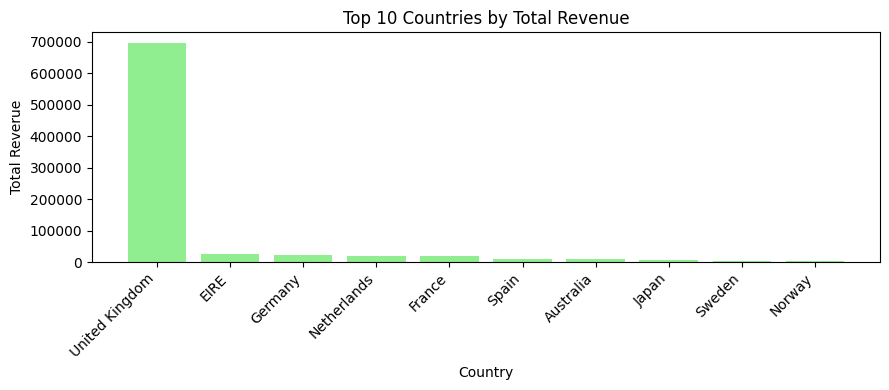

In [40]:
plt.figure(figsize=(9,4))
plt.bar(country_rev. index, country_rev. values, color='lightgreen')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Country')
plt.ylabel('Total Reverue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Finds the maximum 'InvoiceDate'.

In [41]:
df[ 'InvoiceDate' ].max()

Timestamp('2011-01-14 14:47:00')

Gets unique years from 'InvoiceDate'.

In [42]:
df[ 'InvoiceDate' ].dt. year. unique()

array([2010, 2011], dtype=int32)

Extracts month from 'InvoiceDate'.

In [43]:
df['InvoiceDate'].dt.month

,InvoiceDate
0,12
1,12
2,12
3,12
4,12
...,...
58295,1
58296,1
58297,1
58298,1


Creates a 'Month' column, aggregates monthly revenue and unique invoices, and displays the result.

In [44]:
# Create a month column
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly = df.groupby('Month').agg({
  'Revenue' : 'sum',
  'InvoiceNo': 'nunique'
  }).reset_index()

monthly ['Month'] = monthly ['Month' ].dt. to_timestamp ()

monthly

,Month,Revenue,InvoiceNo
0,2010-12-01,570422.73,1400
1,2011-01-01,261194.59,428


Generates a 2x2 subplot grid showing transaction volume by country, top products by quantity, monthly revenue trend, and monthly transaction count.

/tmp/ipykernel_954/2689122853.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0]. set_xticklabels(country_counts.index, rotation=45, ha='right')


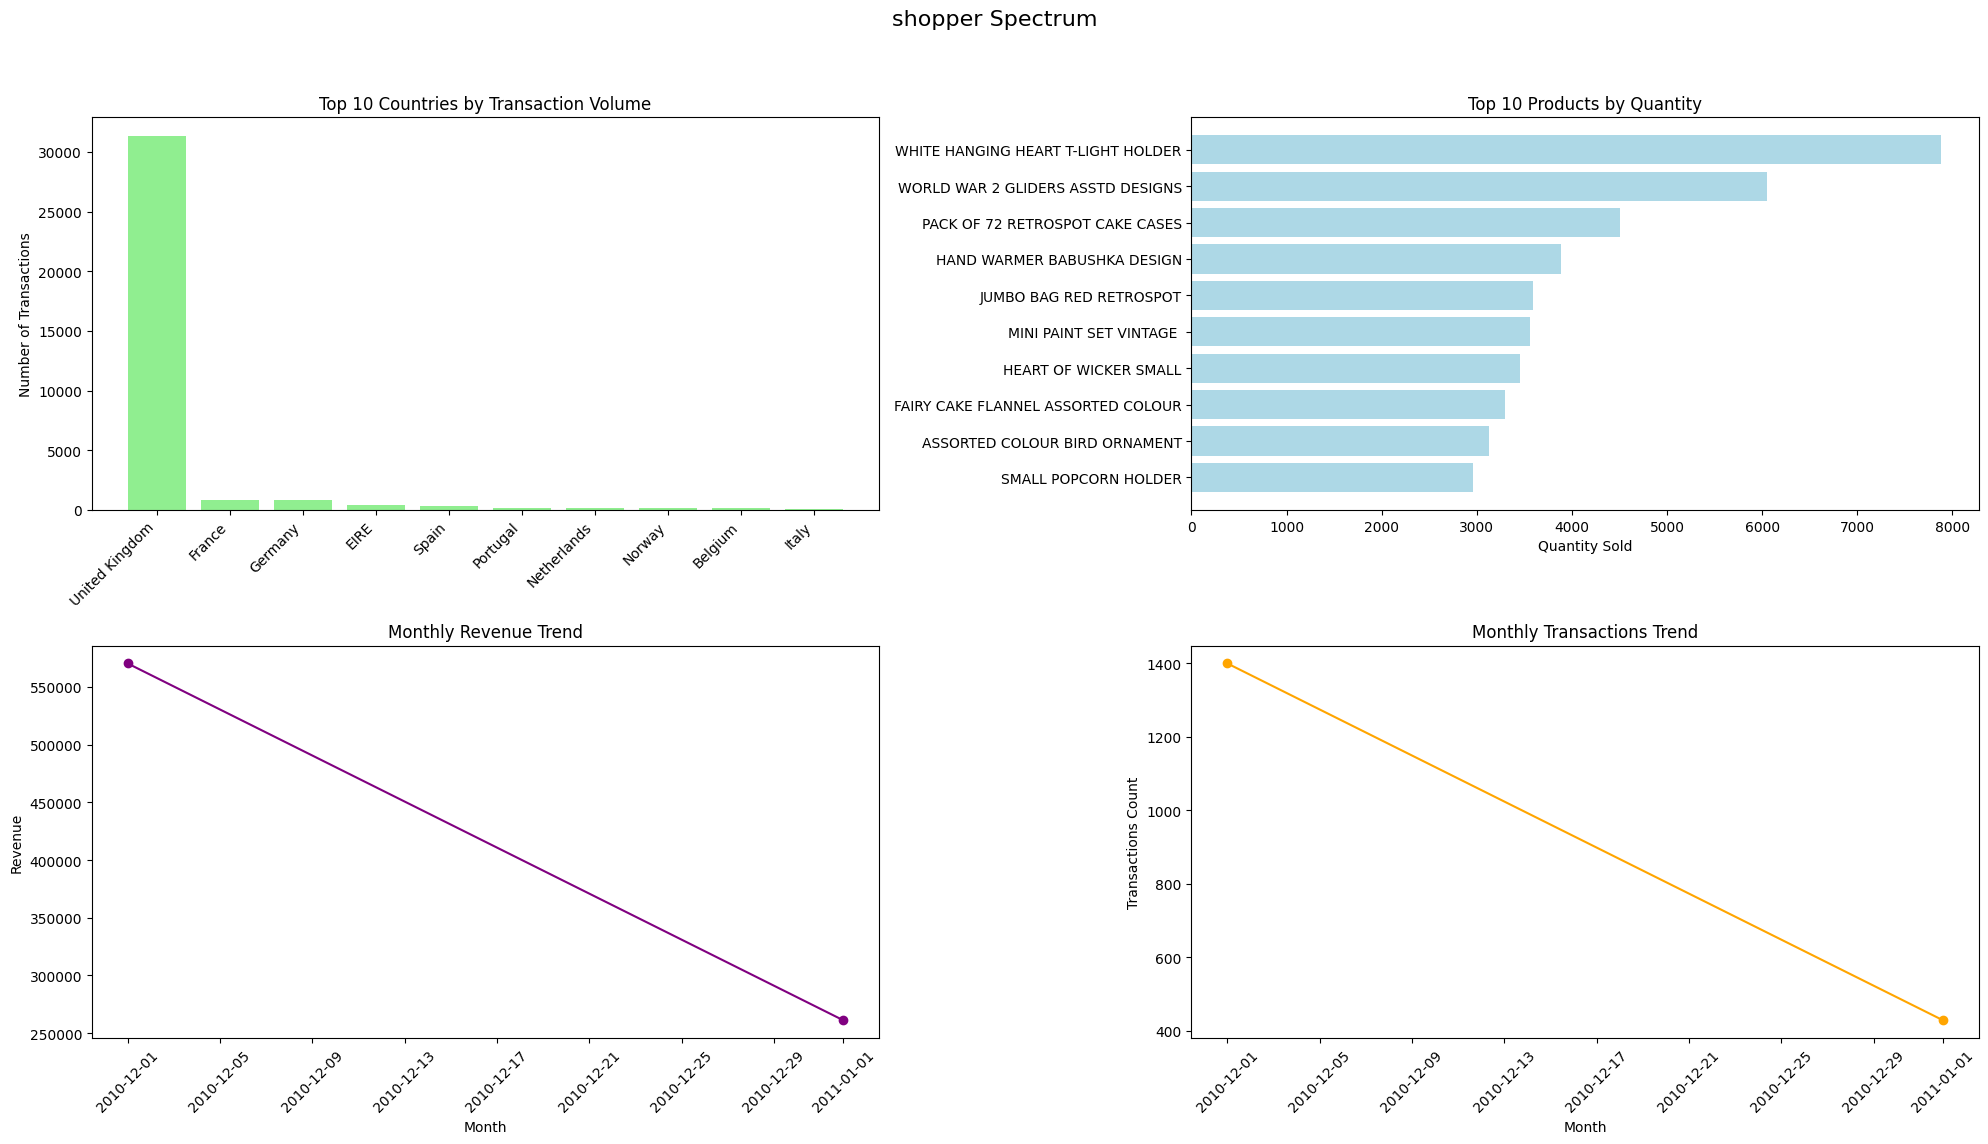

In [45]:
# Create subplots grid 2 rows x 3 columns
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle("shopper Spectrum", fontsize=16)

# 1. Transaction volume by country (top 10)
country_counts = df['Country' ]. value_counts().head(10)
axes[0, 0].bar(country_counts. index, country_counts. values, color='lightgreen')
axes[0, 0].set_title('Top 10 Countries by Transaction Volume')
axes[0, 0]. set_xticklabels(country_counts.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Number of Transactions' )

# 2. Top-selling products by quantity (top 10)
prod_qua = df.groupby(['StockCode','Description' ]) ['Quantity' ].sum() . sort_values(ascending=False).head(10)
axes[0, 1].barh(prod_qua. index.get_level_values(1), prod_qua.values, color='lightblue')
axes[0, 1].set_title('Top 10 Products by Quantity' )
axes[0, 1].invert_yaxis() # so the highest is on top
axes[0, 1].set_xlabel('Quantity Sold')

# 3.Montly revenue Trend
axes[1,0].plot(monthly['Month'], monthly ['Revenue' ], marker='o' , color='purple' )
axes[1,0].set_title("Monthly Revenue Trend")
axes[1,0].set_xlabel("Month")
axes[1,0].set_ylabel("Revenue")
axes [1,0].tick_params(axis='x', rotation=45)

#4. Monthlly Transaction count
axes [1,1].plot(monthly['Month' ], monthly ['InvoiceNo' ], marker='o', color='orange' )
axes[1,1].set_title("Monthly Transactions Trend")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Transactions Count")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Plots monthly revenue and transaction count on a dual-axis chart to compare trends.

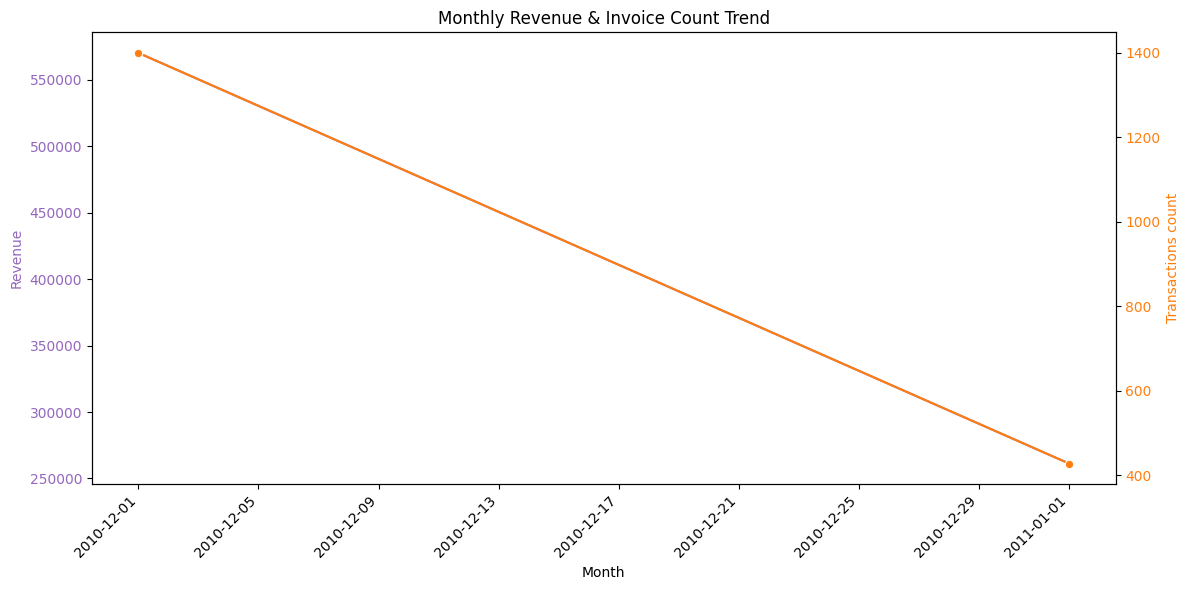

In [46]:
import seaborn as sns
fig, ax1 = plt.subplots(figsize=(12,6))

# Plot Revenue on Left y-axis
color1 = 'tab:purple'
sns.lineplot(data=monthly, x='Month', y='Revenue', marker='o', ax=ax1, color=color1)
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue", color=color1)
ax1. tick_params(axis='y', labelcolor=color1)
plt.xticks(rotation=45, ha='right')

# Create second y-axis that shares the same x-axis
ax2 = ax1.twinx()
color2 = 'tab:orange'
sns.lineplot(data=monthly, x='Month', y='InvoiceNo', marker='o', ax=ax2, color=color2)
ax2.set_ylabel("Transactions count", color=color2)
ax2. tick_params(axis='y', labelcolor=color2)

plt.title("Monthly Revenue & Invoice Count Trend")
fig.tight_layout()
plt.show()

In the above,

* If revenue 1 and number of invoices 1 : business is getting more sales (volume is up).

* If revenue 1 but number of invoices is flat or 1 : maybe each sale is larger (average spend per transaction is up).

* If number of invoices 1 but revenue doesn't increase proportionally : maybe many small transactions are happening (could impact profitability).

In [47]:
print("Dataset Statistics Summary:")
print()
print(f"Total number of customers: {df['CustomerID' ].nunique() }")
print(f"Total number of products: {df['StockCode'].nunique()}")
print(f"Total number of transactions: {df['InvoiceNo'].nunique()}")
print(f"Date covered: {df['InvoiceDate' ].min()} to {df['InvoiceDate'].max()}")
print(f"Total Revenue: Rs. {df['Revenue'].sum():,.2f}")

Dataset Statistics Summary:

Total number of customers: 1067
Total number of products: 2524
Total number of transactions: 1828
Date covered: 2010-12-01 08:26:00 to 2011-01-14 14:47:00
Total Revenue: Rs. 831,617.32


In [48]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [49]:
df.shape

(34867, 10)

##Customer Segmentation : RFM

Calculates `latest_date` and then RFM (Recency, Frequency, Monetary) metrics for each customer.

In [50]:
df['InvoiceDate'].max()
latest_date=df['InvoiceDate' ].max()

Calculates RFM metrics for each customer: Recency (days since last purchase), Frequency (unique invoices), Monetary (total revenue).

In [51]:
rfm =df.groupby('CustomerID').agg({
  'InvoiceDate': 'max',
  'InvoiceNo': 'nunique',
  'Revenue' : 'sum'
}).reset_index()

rfm = df.groupby('CustomerID', as_index=False).agg({
  'InvoiceDate': lambda x: (latest_date - x.max()).days,
  'InvoiceNo': 'nunique',
  'Revenue': 'sum'
})

rfm.rename(columns={
  'InvoiceDate': 'Recency',
  'InvoiceNo': 'Frequency',
  'Revenue': 'Monetary'}, inplace=True)

print(rfm.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary'], dtype='object')


Displays the first 5 rows of the RFM DataFrame.

In [52]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12347.0,37,1,711.79
1,12348.0,28,1,892.80
2,12359.0,2,1,547.50
3,12370.0,28,2,1864.27
4,12377.0,25,1,1001.52


Plots histograms for Recency, Frequency, and Monetary distributions.

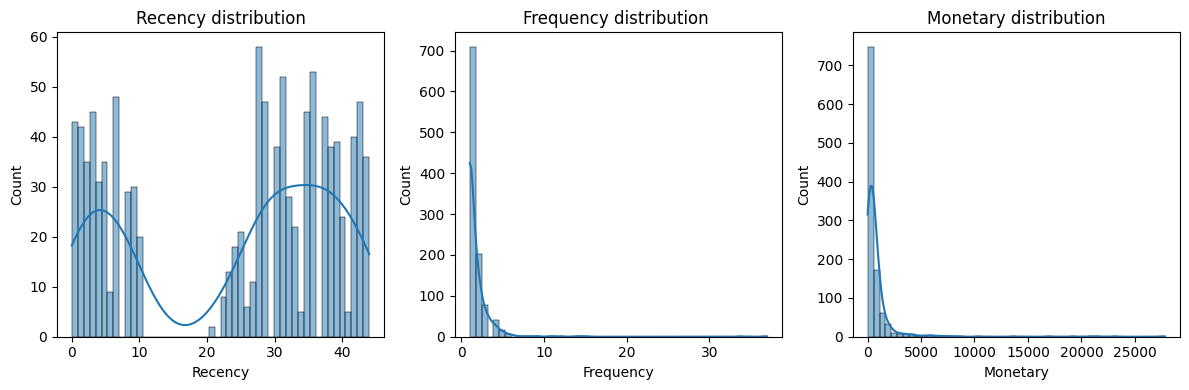

In [53]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins=50, kde=True )
plt.title('Recency distribution' )
plt.subplot(1,3,2)
sns.histplot(rfm['Frequency' ], bins=50, kde=True)
plt.title('Frequency distribution ')
plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins=50, kde=True)
plt. title('Monetary distribution' )
plt.tight_layout()
plt.show()

Visualizes the relationship between Recency, Frequency, and Monetary using a scatter plot.

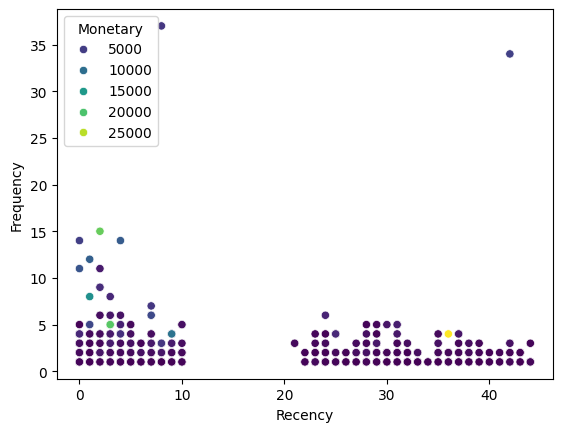

In [54]:
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Monetary', palette='viridis')
plt.show()

Imports `StandardScaler` for data scaling, `KMeans` for clustering, `silhouette_score` for evaluation, and `joblib` for model saving.

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

Initializes `StandardScaler` and scales the RFM features.

In [56]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary' ]])

In [57]:
rfm

,CustomerID,Recency,Frequency,Monetary
0,12347.0,37,1,711.79
1,12348.0,28,1,892.80
2,12359.0,2,1,547.50
3,12370.0,28,2,1864.27
4,12377.0,25,1,1001.52
...,...,...,...,...
1062,18245.0,25,1,365.73
1063,18259.0,37,1,376.30
1064,18260.0,5,2,787.77
1065,18269.0,37,1,168.60


Displays the scaled RFM data.

In [58]:
rfm_scaled

array([[ 0.86120387, -0.35551596, -0.03550338],
       [ 0.26438344, -0.35551596,  0.05955191],
       [-1.45976449, -0.35551596, -0.12177837],
       ...,
       [-1.26082434,  0.14295386,  0.00439663],
       [ 0.86120387, -0.35551596, -0.32075329],
       [-1.0618842 , -0.35551596, -0.35234037]])

Calculates WCSS and Silhouette Scores for k from 2 to 10.

In [59]:
wcss=[]
sil_score=[]
k_range=range(2,11)
for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(rfm_scaled)
  wcss.append(kmeans.inertia_)
  labels = kmeans.labels_
  sil_score.append(silhouette_score(rfm_scaled, labels))

Plots the Elbow Curve (WCSS) and Silhouette Scores to determine optimal k.

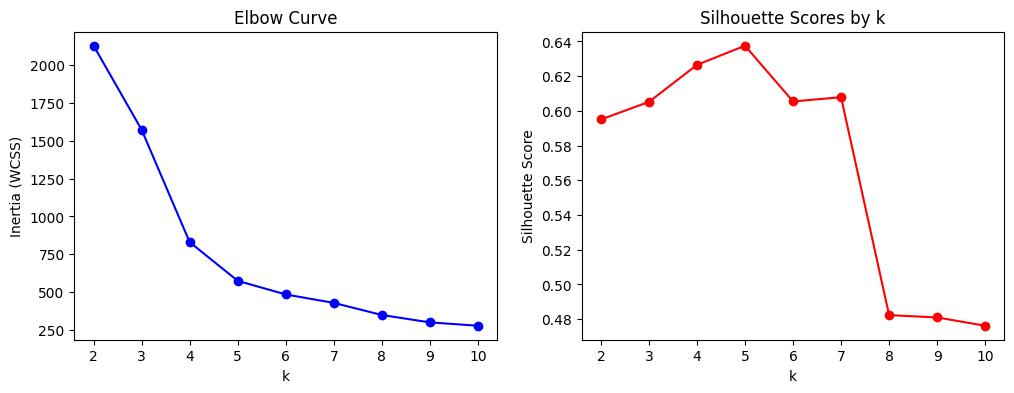

In [60]:
# Here Labels shows which cluster each sample belongs to.
# Then silhouette_score(X, labels) gives a quantitative measure of how good that clustering is.
# array([3, 7, 0, ... , 0, 4, 0])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Curve')
plt.subplot(1,2,2)
plt.plot(k_range, sil_score, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score' )
plt.title('Silhouette Scores by k')
plt.show()

In [61]:
k_best = 4    # choose based on plots + business sense

# Final clustering

kmeans_final = KMeans(n_clusters=k_best, random_state=42)
rfm['Cluster' ] = kmeans_final.fit_predict(rfm_scaled)

kmeans_final.labels_

array([0, 0, 1, ..., 1, 0, 1], dtype=int32)

In [62]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12347.0,37,1,711.79,0
1,12348.0,28,1,892.80,0
2,12359.0,2,1,547.50,1
3,12370.0,28,2,1864.27,0
4,12377.0,25,1,1001.52,0


In [63]:
kmeans_final

KMeans(n_clusters=4, random_state=42)

Calculates mean RFM values and customer count for each cluster to profile segments.

In [64]:
cluster_profile=rfm.groupby('Cluster', as_index=False).agg(
  Recency=('Recency', 'mean' ),
  Frequency=('Frequency','mean' ),
  Monetary=('Monetary','mean' ),
  No_of_Customers=('CustomerID', 'count'))

cluster_profile

,Cluster,Recency,Frequency,Monetary,No_of_Customers
0,0,34.338150,1.309249,420.332124,692
1,1,4.850416,2.096953,965.993740,361
2,2,25.000000,35.500000,4913.755000,2
3,3,4.916667,7.833333,15183.020000,12


1. High-Value/Champions(recent, very frequent, very high spend)
2. Loyal High-Spenders (recent, frequent, high spend but less extreme)
3. Occasional (moderate recency, low frequency, moderate spend)
4. At-Risk/Dormant (old recency, very low frequency, low spend)

Maps numerical cluster labels to descriptive segment names and displays the updated RFM DataFrame.

In [65]:
# Map cluster to segment labels (customize)
label_map = {2: 'High-Value/Champions', 3: 'Loyal / Regular', 0: 'Occasional', 1: 'At-Risk/Dormant'}

rfm['Segment' ] = rfm['Cluster' ].map(label_map)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12347.0,37,1,711.79,0,Occasional
1,12348.0,28,1,892.80,0,Occasional
2,12359.0,2,1,547.50,1,At-Risk/Dormant
3,12370.0,28,2,1864.27,0,Occasional
4,12377.0,25,1,1001.52,0,Occasional


Visualizes the distribution of customers across the different segments using a count plot.

/tmp/ipykernel_954/2236754549.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', color='purple')


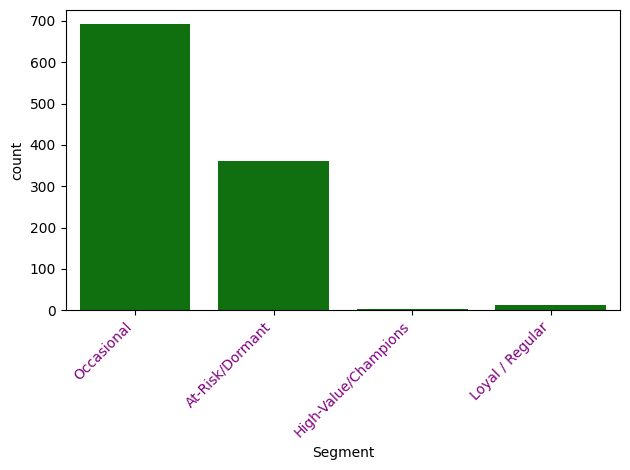

In [66]:
ax = sns.countplot(data=rfm, x='Segment', color='green' )
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', color='purple')
plt.tight_layout()
plt.show()

In [67]:
import pickle

Saves the trained `StandardScaler` and `KMeans` models to disk using `pickle` for future use.

In [68]:
# Save the scaler
with open('scaler.pkl', 'wb') as f:
  pickle.dump(scaler, f)

# Save the clustering model
with open('kmeans_final.pkl', 'wb') as f:
  pickle.dump(kmeans_final, f)

##Recommendation System

1. user based.
2. colaboative based --> user based, item based.
3. cluster based.|
4. hybrid based.

In [69]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34867 entries, 0 to 58299
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    34867 non-null  object        
 1   StockCode    34867 non-null  object        
 2   Description  34867 non-null  object        
 3   Quantity     34867 non-null  int64         
 4   InvoiceDate  34867 non-null  datetime64[ns]
 5   UnitPrice    34867 non-null  float64       
 6   CustomerID   34867 non-null  float64       
 7   Country      34867 non-null  object        
 8   Revenue      34867 non-null  float64       
 9   Month        34867 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), int64(1), object(4), period[M](1)
memory usage: 2.9+ MB


Imports `cosine_similarity` for item similarity and `joblib` for saving the similarity matrix.

In [71]:
from sklearn.metrics.pairwise import cosine_similarity
import joblib

Converts `CustomerID` to int, creates a customer-product pivot table (`cust_prod`), computes item-item cosine similarity (`item_sim`), and stores it in `sim_df`.

In [72]:
# Pre-process: keep relevant columns and positive purchases
df['CustomerID' ] = df['CustomerID'].astype(int)

# Create customer-product matrix (customers x products) using purchase count or revenue
cust_prod = df.pivot_table(
  index='CustomerID',
  columns='Description',
  values='Quantity',           # or values='Revenue'
  aggfunc='sum',
  fill_value=0)

# Compute item-item cosine similarity
item_sim = cosine_similarity(cust_prod.T)
sim_df = pd.DataFrame(item_sim, index=cust_prod.columns, columns=cust_prod.columns)

# Persist similarity matrix for app
#joblib.dump(sim_df, 'item_similarity_matrix. joblib')

cust_prod. head()


Description,4 PURPLE FLOCK DINNER CANDLES,OVAL WALL MIRROR DIAMANTE,SET 2 TEA TOWELS I LOVE LONDON,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,...,YOU'RE CONFUSING ME METAL SIGN,YULETIDE IMAGES GIFT WRAP SET,YULETIDE IMAGES S/6 PAPER BOXES,ZINC FINISH 15CM PLANTER POTS,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC METAL HEART DECORATION,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK
CustomerID,,,,,,,,,,,,,,,,,,,,,
12347,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12359,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12370,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,20,0,0,0
12377,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Displays the raw item similarity array.

In [73]:
item_sim

array([[1.        , 0.        , 0.        , ..., 0.003134  , 0.        ,
        0.        ],
       [0.        , 1.        , 0.0025822 , ..., 0.0021253 , 0.12598816,
        0.00486579],
       [0.        , 0.0025822 , 1.        , ..., 0.00385253, 0.        ,
        0.        ],
       ...,
       [0.003134  , 0.0021253 , 0.00385253, ..., 1.        , 0.        ,
        0.00986556],
       [0.        , 0.12598816, 0.        , ..., 0.        , 1.        ,
        0.02206915],
       [0.        , 0.00486579, 0.        , ..., 0.00986556, 0.02206915,
        1.        ]])

In [74]:
sim_df

Description,4 PURPLE FLOCK DINNER CANDLES,OVAL WALL MIRROR DIAMANTE,SET 2 TEA TOWELS I LOVE LONDON,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,...,YOU'RE CONFUSING ME METAL SIGN,YULETIDE IMAGES GIFT WRAP SET,YULETIDE IMAGES S/6 PAPER BOXES,ZINC FINISH 15CM PLANTER POTS,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC METAL HEART DECORATION,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003134,0.000000,0.000000
OVAL WALL MIRROR DIAMANTE,0.000000,1.000000,0.002582,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.006530,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002125,0.125988,0.004866
SET 2 TEA TOWELS I LOVE LONDON,0.000000,0.002582,1.000000,0.000000,0.0,0.009739,0.005164,0.002416,0.001020,0.002191,...,0.000000,0.000970,0.016350,0.000317,0.000000,0.000000,0.000000,0.003853,0.000000,0.000000
10 COLOUR SPACEBOY PEN,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.053814,...,0.005393,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000073,0.000000,0.024448
12 COLOURED PARTY BALLOONS,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZINC HEART LATTICE CHARGER SMALL,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.150756,0.000000,0.000000,0.000000
ZINC HEART LATTICE T-LIGHT HOLDER,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.150756,0.150756,1.000000,0.069207,0.000000,0.000000
ZINC METAL HEART DECORATION,0.003134,0.002125,0.003853,0.000073,0.0,0.010687,0.000000,0.436376,0.003987,0.003682,...,0.012740,0.000000,0.001922,0.000000,0.000000,0.000000,0.069207,1.000000,0.000000,0.009866


Function to get top 5 similar products for a given product.

In [75]:
# skip itself at index 0

# Assume you already have `sim_df (product-product similarity DataFrame)
# and you have Loaded it or computed it as described.

prod_name = input("Enter product description exactly: ")

if prod_name not in sim_df.index:
  print("Product not found. Please check spelling or try another.")
else:
  sims = sim_df[prod_name].sort_values(ascending=False)
  top5 = sims.index[1:6]
  print("Top 5 similar products:")
  for i, p in enumerate(top5, start=1):
    print(f"{i}. {p} (similarity = {sims[p]:.3f})")

Enter product description exactly: RED WOOLLY HOTTIE WHITE HEART.
Top 5 similar products:
1. PINK MARSHMALLOW SCARF KNITTING KIT (similarity = 0.948)
2. UNION JACK FLAG PASSPORT COVER  (similarity = 0.945)
3. LADS ONLY TISSUE BOX (similarity = 0.944)
4. CREAM SLICE FLANNEL PINK SPOT  (similarity = 0.924)
5. EDWARDIAN PARASOL PINK (similarity = 0.921)


Enter product description exactly: RED WOOLLY HOTTIE WHITE HEART.


Top 5 similar products:
1. PINK MARSHMALLOW SCARF KNITTING KIT (similarity = 0.973)
2. CREAM SLICE FLANNEL PINK SPOT (similarity = 0.966)
3. 6 CHOCOLATE LOVE HEART T-LIGHTS (similarity - 0.957)
4. LADS ONLY TISSUE BOX (similarity = 0.952)
5. ROSE SCENT CANDLE IN JEWELLED BOX (similarity = 0.924)

In [76]:
joblib.dump(sim_df, 'item_similarity_matrix.joblib')

['item_similarity_matrix.joblib']

In [77]:
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"joblib version: {joblib.__version__}")
print(f"pickle version: {pickle.format_version}")

pandas version: 2.2.2
numpy version: 2.0.2
matplotlib version: 3.10.0
seaborn version: 0.13.2
scikit-learn version: 1.6.1
joblib version: 1.5.3
pickle version: 4.0
